# Lab 2: Maze Solving Using BFS, DFS, and A* Search

## Fundamentals of Artificial Intelligence

**Name:** Renelle V. Alemios  
**Course:**  CS-FUNDAI

**Section:**  09282-FUNDAI
**Date:** 08/20/2026  

**GitHub URL:** https://github.com/Renelle24/FUNDAI-Laboratories-Alemios.git

## Description
This laboratory implements BFS, DFS, and A* Search to solve a maze.
The search results are visualized using matplotlib.



In [1]:
from collections import deque
import heapq
import numpy as np
import matplotlib.pyplot as plt

## Maze Class

The 'Maze' class stores the grid, start position, and goal position.
The value 'a' represents an open cell.
The value '1' represents a wall.

In [2]:
class Maze:
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0]) if self.rows > 0 else 0

    def inside(self, pos):
        r, c = pos
        return 0 <= r < self.rows and 0 <= c < self.cols

    def passable(self, pos):
        if not self.inside(pos):
            return False
        r, c = pos
        return self.grid[r][c] == 0

    def neighbors(self, pos):
        r, c = pos
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        result = []
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            next_pos = (nr, nc)
            if self.passable(next_pos):
                result.append(next_pos)
        return result

## SearchResult Class

The 'SearchResult' class stores the output of each search algorith.
It includes the algorithn name, success status, path, visited order, and parent
nap.

In [3]:
class SearchResult:
    def __init__(self, algorithm, success, path, visited_order, parent, root):
        self.algorithm = algorithm
        self.success = success
        self.path = path
        self.visited_order = visited_order
        self.parent = parent
        self.root = root
        self.path_set = set(path)
        self.visited_set = set(visited_order)

    @property
    def path_length(self):
        return len(self.path)

    @property
    def nodes_expanded(self):
        return len(self.visited_order)

    def summary(self):
        print(f"Algorithm: {self.algorithm}")
        print(f"Success: {self.success}")
        print(f"Path length: {self.path_length}")
        print(f"Nodes expanded/popped: {self.nodes_expanded}")
        print(f"Path: {self.path}")
        print("-" * 50)

## SearchSolver Class

The 'SearchSolver' class contains the implementation of BFS, DFS, and Ax Search.

In [4]:
from collections import deque
import heapq

class SearchSolver:
    def __init__(self, maze):
        self.maze = maze

    def _reconstruct_path(self, parent, goal):
        path = []
        current = goal
        while current is not None:
            path.append(current)
            current = parent.get(current)
        path.reverse()
        return path

    def _heuristic(self, a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def bfs(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
            return SearchResult("BFS", False, [], [], {start: None}, start)

        frontier = deque([start])
        visited = {start}
        parent = {start: None}
        visited_order = []
        success = False

        while frontier:
            current = frontier.popleft()
            visited_order.append(current)

            if current == goal:
                success = True
                break

            for neighbor in self.maze.neighbors(current):
                if neighbor not in visited:
                    visited.add(neighbor)
                    parent[neighbor] = current
                    frontier.append(neighbor)

        path = self._reconstruct_path(parent, goal) if success else []

        return SearchResult(
            algorithm="BFS",
            success=success,
            path=path,
            visited_order=visited_order,
            parent=parent,
            root=start
        )

    def dfs(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
            return SearchResult("DFS", False, [], [], {start: None}, start)

        frontier = [start]
        visited = {start}
        parent = {start: None}
        visited_order = []
        success = False

        while frontier:
            current = frontier.pop()
            visited_order.append(current)

            if current == goal:
                success = True
                break

            # reversed is used so that the first neighbor appears explored first
            for neighbor in reversed(self.maze.neighbors(current)):
                if neighbor not in visited:
                    visited.add(neighbor)
                    parent[neighbor] = current
                    frontier.append(neighbor)

        path = self._reconstruct_path(parent, goal) if success else []

        return SearchResult(
            algorithm="DFS",
            success=success,
            path=path,
            visited_order=visited_order,
            parent=parent,
            root=start
        )

    def astar(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
            return SearchResult("A* Search", False, [], [], {start: None}, start)

        counter = 0
        open_heap = []
        heapq.heappush(open_heap, (0, counter, start))

        g_score = {start: 0}
        parent = {start: None}
        visited = set()
        visited_order = []
        success = False

        while open_heap:
            f, _, current = heapq.heappop(open_heap)

            if current in visited:
                continue

            visited.add(current)
            visited_order.append(current)

            if current == goal:
                success = True
                break

            for neighbor in self.maze.neighbors(current):
                tentative_g = g_score[current] + 1

                if tentative_g < g_score.get(neighbor, float('inf')):
                    g_score[neighbor] = tentative_g
                    f_score = tentative_g + self._heuristic(neighbor, goal)

                    parent[neighbor] = current
                    counter += 1
                    heapq.heappush(open_heap, (f_score, counter, neighbor))

        path = self._reconstruct_path(parent, goal) if success else []

        return SearchResult(
            algorithm="A* Search",
            success=success,
            path=path,
            visited_order=visited_order,
            parent=parent,
            root=start
        )

## Sample Maze

The maze uses:

- '0' for open cells
- '1' for walls

In [5]:
grid = [
    [0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0],
]
start = (0, 0)
goal = (6, 6)

maze = Maze(grid, start, goal)
solver = SearchSolver(maze)

In [6]:
bfs_result = solver.bfs()
dfs_result = solver.dfs()
astar_result = solver.astar()

In [7]:
bfs_result. summary()
dfs_result. summary()
astar_result.summary()

Algorithm: BFS
Success: True
Path length: 17
Nodes expanded/popped: 24
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------
Algorithm: DFS
Success: True
Path length: 17
Nodes expanded/popped: 17
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------
Algorithm: A* Search
Success: True
Path length: 17
Nodes expanded/popped: 21
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------


## Visualization Using matplotlib

The visualization shows:

- Black: wall
- White: open cell
- Light blue: visited/expanded cells
- Yellow: final path
- Green: start
- Red: goal

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_search(maze, result, title="Search Result"):
    img = np.ones((maze.rows, maze.cols, 3))

    # Draw walls
    for r in range(maze.rows):
        for c in range(maze.cols):
            if maze.grid[r][c] == 1:
                img[r, c] = (0.1, 0.1, 0.1)

    if result is not None:
        # Draw visited/expanded cells
        for r, c in result.visited_set:
            if maze.grid[r][c] == 0:
                img[r, c] = (0.75, 0.87, 1.0)

        # Draw final path
        for r, c in result.path_set:
            if maze.grid[r][c] == 0:
                img[r, c] = (1.0, 0.85, 0.3)

    # Draw start and goal
    img[maze.start] = (0.2, 0.8, 0.2)
    img[maze.goal] = (0.9, 0.2, 0.2)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

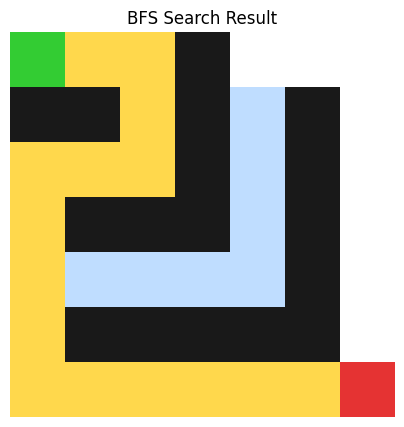

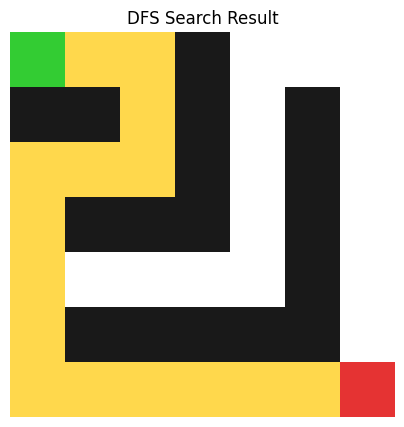

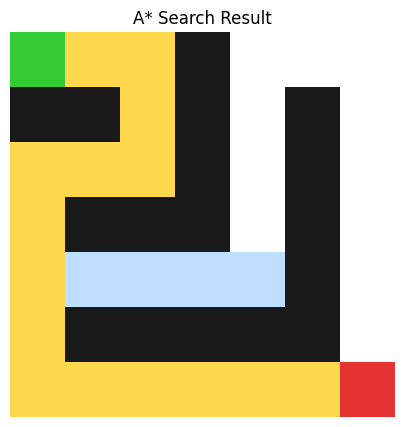

In [9]:
visualize_search(maze, bfs_result, "BFS Search Result")
visualize_search(maze, dfs_result, "DFS Search Result")
visualize_search(maze, astar_result, "A* Search Result")

## Search Tree Documentation

The search tree is generated from the parent map.
Each child node is connected to its predecessor.

In [10]:
def search_tree_text(result, max_lines=100):
    children = {}
    for child, predecessor in result.parent.items():
        if predecessor is not None:
            if predecessor not in children:
                children[predecessor] = []
            children[predecessor].append(child)

    for node in children:
        children[node].sort()

    lines = []

    def build(node, depth):
        if len(lines) >= max_lines:
            return
        lines.append("  " * depth + str(node))
        for child in children.get(node, []):
            build(child, depth + 1)

    build(result.root, 0)

    if len(lines) >= max_lines:
        lines.append("... search tree truncated for report")

    return "\n".join(lines)

In [11]:
print("BFS Search Tree")
print(search_tree_text(bfs_result, max_lines=80))

print("\nDFS Search Tree")
print(search_tree_text(dfs_result, max_lines=80))

print("\nA* Search Tree")
print(search_tree_text(astar_result, max_lines=80))

BFS Search Tree
(0, 0)
  (0, 1)
    (0, 2)
      (1, 2)
        (2, 2)
          (2, 1)
            (2, 0)
              (3, 0)
                (4, 0)
                  (4, 1)
                    (4, 2)
                      (4, 3)
                        (4, 4)
                          (3, 4)
                            (2, 4)
                              (1, 4)
                                (0, 4)
                  (5, 0)
                    (6, 0)
                      (6, 1)
                        (6, 2)
                          (6, 3)
                            (6, 4)
                              (6, 5)
                                (6, 6)

DFS Search Tree
(0, 0)
  (0, 1)
    (0, 2)
      (1, 2)
        (2, 2)
          (2, 1)
            (2, 0)
              (3, 0)
                (4, 0)
                  (4, 1)
                  (5, 0)
                    (6, 0)
                      (6, 1)
                        (6, 2)
                          (6, 3)
               

In [12]:
def expansion_report(result, first_n=20):
    print(f"{result.algorithm} expansion order, first {first_n} nodes:")
    print(result.visited_order[:first_n])
    print("-" * 50)

expansion_report(bfs_result)
expansion_report(dfs_result)
expansion_report(astar_result)

BFS expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (4, 1), (6, 0), (4, 2), (6, 1), (4, 3), (6, 2), (4, 4), (6, 3), (3, 4), (6, 4)]
--------------------------------------------------
DFS expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------
A* Search expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (4, 1), (6, 0), (4, 2), (6, 1), (4, 3), (6, 2), (4, 4), (6, 3), (6, 4), (6, 5)]
--------------------------------------------------


### BFS
BFS explores the maze level by level. It is useful for finding a shortest path
when all move costs are equal.

### DFS
DFS explores one branch deeply before backtracking. It may find a solution
quickly, but the path may not be short.

### A* Search
A* uses both actual cost from the start and estimated cost to the goal. With
Manhattan distance, it is often more efficient than BFS.

### Observation
Since the maze has only one valid route from start to goal, all three algorithms found the same path (17 nodes, 16 steps). The difference lies in how many extra nodes each algorithm explored before/while finding this path. DFS was the most efficient in terms of node discovery since it quickly abandoned the short dead-end branch at (4,1). A* discovered more nodes than DFS because the Manhattan distance heuristic led it to investigate the (4,4)-(3,4) area, which looked promising (closer to the goal in straight-line distance) but was actually a dead end due to the wall blocking column 5. BFS discovered the most nodes overall, as it systematically expanded level-by-level regardless of direction, fully exploring the (0,4) dead-end branch before reaching the goal.

1. Which algorithm found the shortest path?


Answer: All three algorithms (BFS, DFS, and A*) found the same shortest path of 17 nodes (16 steps), since the maze only has one valid route from start (0,0) to goal (6,6) — the wall structure forces all paths through column 0. BFS and A* are guaranteed to find the shortest path by design; in this case, DFS happened to find the same shortest path too, since there was no alternative (shorter or longer) route available.

2. Which algorithm expanded the fewest nodes?

Answer: DFS expanded the fewest nodes. It quickly abandoned the short dead-end branch at (4,1) since that branch had no further unvisited neighbors, allowing DFS to backtrack immediately and continue toward the goal via (5,0). A* expanded more nodes than DFS because its Manhattan distance heuristic led it to explore the (4,4)-(3,4) dead-end area, which appeared closer to the goal in straight-line distance despite being blocked by a wall. BFS expanded the most nodes overall, since it explores level-by-level in all directions regardless of proximity to the goal, fully exploring the (0,4) dead-end branch before reaching the goal.

3. Why is Manhattan distance suitable for this maze?

Answer: Manhattan distance (|x1-x2| + |y1-y2|) is suitable because the maze only allows 4-directional movement (up, down, left, right) — no diagonal moves. This heuristic estimates the minimum number of horizontal and vertical steps needed to reach the goal, which matches exactly how movement works in this maze. Since it never overestimates the true remaining cost (it's admissible), A* using Manhattan distance is guaranteed to still find the optimal shortest path, while also being more efficient than a heuristic that doesn't match the movement model.

4. How does the parent map help reconstruct the path?

Answer: The parent map is a dictionary that records, for each visited node, which node discovered/expanded it first. Once the goal is reached, the algorithm uses _reconstruct_path() to trace backward from the goal node through its parent, then that parent's parent, and so on, until it reaches the start node (whose parent is None). This backward chain of nodes is then reversed to produce the final path in correct start-to-goal order. Without the parent map, the algorithm would only know which nodes were visited, but not how they connect into an actual path.

5. Why is repeated-state checking important?

Answer: Repeated-state checking (using the visited set) prevents the algorithm from revisiting and re-expanding the same cell multiple times. Without it, the search could loop infinitely — especially in DFS, which could cycle back and forth between neighboring cells forever — or waste significant time and memory re-processing nodes that were already explored. It also keeps the nodes_expanded count accurate, ensuring each node is only counted once, and guarantees the search algorithms terminate correctly and efficiently.

## Reflection

Challenges Encountered

Debugging OCR-corrupted code was tricky — errors like _init_ instead of __init__, @ instead of 0, and misplaced brackets caused confusing NameError and IndentationError messages that didn't point directly to the real typo.
Making sure classes and cells were run in the correct order in the notebook (Maze → SearchResult → SearchSolver → grid setup) to avoid NameError: name 'X' is not defined.
Understanding how the parent map and heuristic function work together, especially in A*, to reconstruct paths correctly and avoid infinite loops.

What I Learned

How BFS, DFS, and A* differ in exploration behavior even when they find the same path — BFS explores broadly level-by-level, DFS commits deep into one branch, and A* uses a heuristic (Manhattan distance) to search more efficiently toward the goal.
The importance of a visited set for repeated-state checking, without which searches could loop forever or waste resources re-expanding the same nodes.
How a parent map enables path reconstruction by tracing backward from the goal to the start, then reversing the sequence.